In [ ]:
!pip install inference-sdk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.90
    Uninstalling opencv-python-4.13.0.90:
      Successfully uninstalled opencv-python-4.13.0.90
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.13.3
    Uninstalling aiohttp-3.13.3:
      Successfully uninstalled aiohttp-3.13.3


In [ ]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Photo';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for capture button to be clicked.
      await new Promise(resolve => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      document.body.removeChild(div);
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

try:
  # 1. Capture the photo (a pop-up will ask for camera permission)
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # 2. Read the captured image into an OpenCV format
  img = cv2.imread(filename)

  # 3. Display the image (optional: convert to grayscale or other operations)
  # img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Example operation
  display(Image(filename))

except Exception as err:
  # Errors occur if no camera is connected or permission is denied
  print(str(err))
  print('Could not access the camera. Please ensure a camera is connected and permissions are granted.')



<IPython.core.display.Javascript object>


KeyboardInterrupt



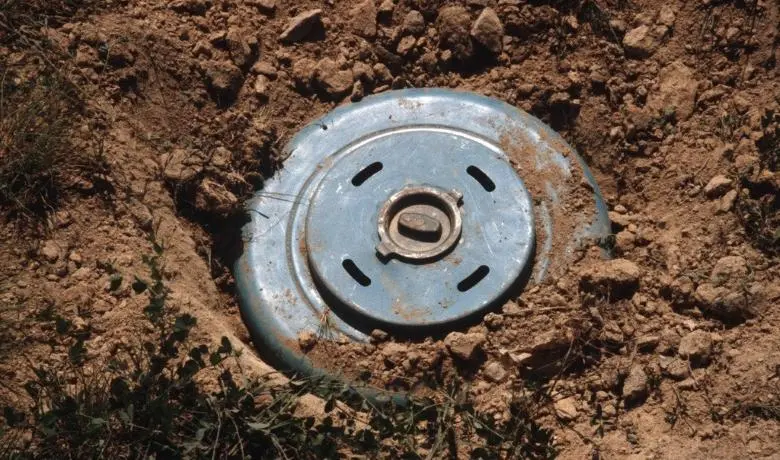

[{'width': 442.0, 'height': 286.0, 'x': 361.0, 'y': 216.0, 'confidence': 0.7749362587928772, 'class_id': 0, 'class': 'Landmine', 'detection_id': '471bab3e-9a72-4067-b72c-1198ffa01342', 'parent_id': 'image'}]


In [ ]:
from inference_sdk import InferenceHTTPClient
from google.colab.patches import cv2_imshow

client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="wFTqKNe6L4Ms2PdmOQYn"
)

image_path = "image.webp"
img = cv2.imread(image_path)

result = client.run_workflow(
    workspace_name="arkasaha",
    workflow_id="custom-workflow",
    images={
        "image": image_path #pohoto
    },
    use_cache=True
)

prediction = result[0]['predictions']['predictions']
cv2_imshow(img)
print(prediction, end="\n")
# print(f"Confidence: {prediction[0]}\nClass: {prediction[0]}")

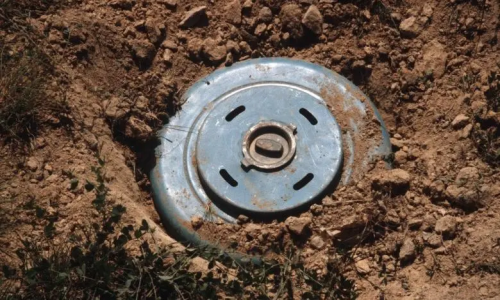

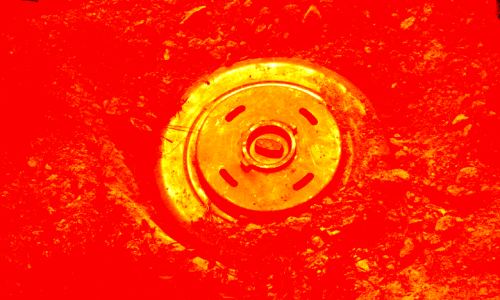

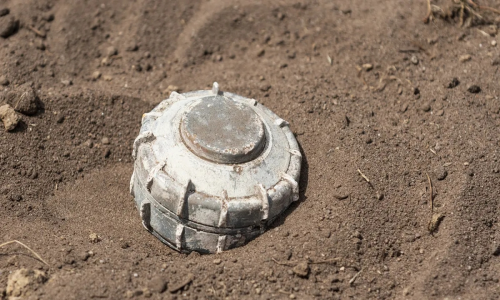

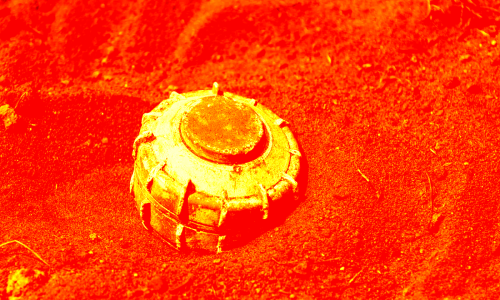

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

def img_to_thermal_with_hot_circles(image_path, output_path='thermal_output.jpg'):
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not load image.")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 11)
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
        param1=50, param2=30, minRadius=10, maxRadius=200
    )

# heat
    heat_mask = np.zeros_like(gray)

    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            center = (i[0], i[1])
            radius = i[2]
            cv2.circle(heat_mask, center, radius, 255, -1)

            cv2.circle(heat_mask, center, int(radius*1.2), 100, -1)

    enhanced_gray = cv2.max(gray, heat_mask)

    thermal_img = cv2.applyColorMap(enhanced_gray, cv2.COLORMAP_HOT)

    cv2.imwrite(output_path, thermal_img)
    new_width = 500
    new_height = 300
    resized_dim = (new_width, new_height)
    resized_image = cv2.resize(img, resized_dim, interpolation=cv2.INTER_AREA)
    resized_th_image = cv2.resize(thermal_img, resized_dim, interpolation=cv2.INTER_AREA)
    cv2_imshow(resized_image)
    cv2_imshow(resized_th_image)


img_to_thermal_with_hot_circles('image.webp')
print("\n")
print("=="*50)
print("\n")
img_to_thermal_with_hot_circles('landmine22.jpeg')


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [ ]:
dataset_path = "dataset"

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 532 files belonging to 2 classes.
Using 426 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 532 files belonging to 2 classes.
Using 106 files for validation.


In [ ]:
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

Classes found: ['landmine', 'none']


In [ ]:
#transfer learning
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

In [ ]:
model = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# train
history = model.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8590 - loss: 0.3257 - val_accuracy: 0.8868 - val_loss: 0.2934
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8517 - loss: 0.3148 - val_accuracy: 0.8868 - val_loss: 0.2766
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8623 - loss: 0.3336 - val_accuracy: 0.9057 - val_loss: 0.2672
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8662 - loss: 0.3609 - val_accuracy: 0.8962 - val_loss: 0.2667
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8927 - loss: 0.2732 - val_accuracy: 0.9057 - val_loss: 0.2742
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9089 - loss: 0.2692 - val_accuracy: 0.8868 - val_loss: 0.2584
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8515 - loss: 0.3061 - val_accuracy: 0.8868 - val_loss: 0.2503
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9078 - loss: 0.2450 - val_accuracy: 0.8868 - val_loss:

In [ ]:
model.save('image_classifier.h5')
print("Model saved as 'image_classifier.h5'")

Model saved as 'image_classifier.h5'


In [ ]:
model = tf.keras.models.load_model('image_classifier-2.h5')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
class_names = ["landmine", "none"]

In [ ]:
def identify_mine(img):
  image_path = img
  img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
  img_array = tf.keras.preprocessing.image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  predictions = model.predict(img_array)
  predicted_class_idx = np.argmax(predictions[0])
  confidence = predictions[0][predicted_class_idx]
  img = mpimg.imread(image_path)
  plt.figure(figsize=(5, 4))

  # plt.imshow(img)

  # print(f"Physical Condition Indentified: \033[1m{class_names[predicted_class_idx].upper()}\033[0m")
  # print(f"Confidence: {confidence:.2%}")
  caption = f"\nIndentified:\n{class_names[predicted_class_idx].upper()}\nConfidence: {confidence:.2%}"
  # print("\nAll probabilities:")
  # for i, prob in enumerate(predictions[0]):
  #     print(f"  {class_names[i]}: {prob:.2%}")
  plt.figtext(0.5,0, caption, wrap=True, horizontalalignment='center', fontsize=15)
  plt.imshow(img)
  plt.axis('off')
  plt.legend("")
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


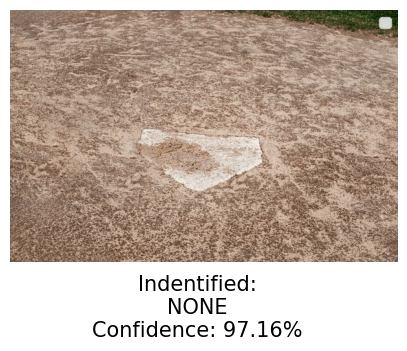

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


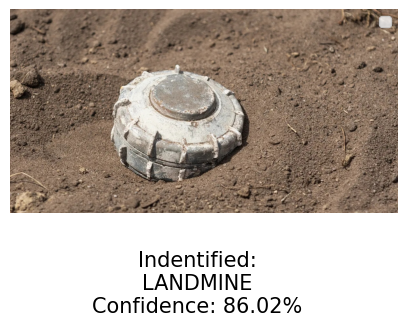

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


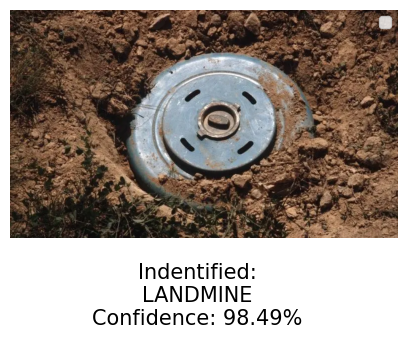

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


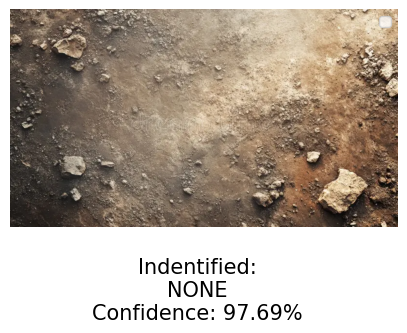

In [ ]:
identify_mine("plates.webp")
identify_mine("landmine22.jpeg")
identify_mine("image.webp")
identify_mine("ground.webp")

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "test_ds",
    validation_split=0.7,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)
results = model.evaluate(test_ds)

In [ ]:
accuracy = results[1]
loss = results[0]
print(f'Accuracy: {(accuracy-loss) * 100:.2f}%')
# print(results)

Accuracy: 94.53%
